# 11 — Mejoras de bajo coste: predicción directa, corrección de sesgo y ensembles

**RESPIR-AI · TFG** — Cuatro técnicas baratas que no requieren re-entrenar modelos fundacionales,
evaluadas sobre las mismas 36 ventanas del protocolo v2 (H ∈ {6,12,24,48}, semilla 42):

- **A. XGBoost directo multi-horizonte**: un modelo por paso (48 modelos) con retardos [1..48, 168]
  y medias móviles de 24 y 168 h, frente al recursivo del cuaderno 03.
- **B. Corrección de sesgo en línea**: a cada predicción se le resta el error medio del mismo modelo
  en las 24 h anteriores al origen (predicción auxiliar desde t0−24; sin fuga, solo datos ≤ t0).
- **C. Ensemble de contextos** de Chronos-2: media de las predicciones zero-shot con C ∈ {128, 256, 512}.
- **D. Ensemble entre familias**: media simple y ponderada por 1/MAE de validación (pesos calculados
  en el split de VALIDACIÓN) de XGBoost + Chronos-2 + TTM, con y sin corrección de sesgo.

Todas las predicciones por ventana se guardan en `results/predicciones_nb11.parquet`.

In [1]:
# Raíz del repositorio como cwd
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import time, warnings
import numpy as np, pandas as pd, torch
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursiveMultiSeries
from chronos import Chronos2Pipeline
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from scipy import stats
warnings.filterwarnings("ignore")
from common_eval import *
import common_eval as CE

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)
test_ilocs = [o['iloc'] for o in origins]
train_end = proto['particion']['train']['fin']
val_start = proto['particion']['val']['inicio']
val_end   = proto['particion']['val']['fin']
seg = df.segment_id.to_numpy()

# orígenes de validación (contexto 512 y futuro 48 intra-segmento, paso 24, dentro de val)
val_mask = (df.index >= val_start) & (df.index <= val_end)
val_ilocs, last = [], -10**9
for i in np.where(val_mask)[0]:
    s = seg[i]
    if s < 0 or i - last < 24: continue
    if i-511 < 0 or (seg[i-511:i+1] != s).any(): continue
    if i+48 >= len(df) or (seg[i+1:i+49] != s).any(): continue
    if not df.index[i+48] <= pd.Timestamp(val_end): continue
    val_ilocs.append(i); last = i
Y_val = np.stack([df['our'].iloc[i+1:i+49].to_numpy() for i in val_ilocs])
# verdad de las 24 h previas a cada origen (para el sesgo)
Y_back = np.stack([df['our'].iloc[i-23:i+1].to_numpy() for i in test_ilocs])

PREDS = {}    # config -> (36,48)
BACK24 = {}   # config -> (36,24) predicción desde t0-24
print(f"orígenes test: {len(origins)} | val: {len(val_ilocs)} | NaN en Y_back: {np.isnan(Y_back).sum()}")

orígenes test: 36 | val: 23 | NaN en Y_back: 0


## A. XGBoost directo multi-horizonte

`ForecasterDirect` de skforecast exige una serie sin huecos, incompatible con los segmentos de esta
planta, así que el directo se implementa de forma explícita: **48 XGBRegressor, uno por paso h**,
con las mismas features para todos (retardos 1–48 y 168 de la OUR, medias móviles de 24 y 168 h) y,
en la variante F, la meteo real de la hora objetivo t0+h como exógena futura. Las filas de
entrenamiento exigen que t0 y t0+h caigan en el mismo segmento (sin fuga ni cruce de huecos);
XGBoost tolera de forma nativa los NaN en features. Búsqueda de hiperparámetros walk-forward en
validación como en el cuaderno 03 (rejilla reducida lr × profundidad, evaluada en los pasos
representativos h ∈ {1, 12, 24, 48} para no entrenar 48 modelos por combinación).

In [2]:
y_masked = df['our'].where(df.segment_id >= 0)
FEAT = pd.DataFrame(index=df.index)
for j in list(range(1, 49)) + [168]:
    FEAT[f"lag{j}"] = y_masked.shift(j-1)
FEAT["rmean24"] = y_masked.rolling(24, min_periods=12).mean()
FEAT["rmean168"] = y_masked.rolling(168, min_periods=84).mean()
meteo_full = df[METEO].astype(float)
seg_s = pd.Series(seg, index=df.index)

def direct_fit_predict(hs, end_ts, pred_ilocs, use_meteo, params):
    """Entrena un modelo por paso h (train hasta end_ts) y predice en pred_ilocs. -> (n,len(hs))"""
    out = np.full((len(pred_ilocs), len(hs)), np.nan)
    for k, h in enumerate(hs):
        tgt = y_masked.shift(-h)
        ok = (df.index <= pd.Timestamp(end_ts)) & tgt.notna() & (seg_s.shift(-h) == seg_s) & (seg >= 0)
        X = FEAT[ok]; yv = tgt[ok]
        if use_meteo:
            X = pd.concat([X, meteo_full.shift(-h)[ok].add_suffix("_fut")], axis=1)
        m = XGBRegressor(**params, random_state=42, n_jobs=8, objective="reg:squarederror")
        m.fit(X, yv)
        Xp = FEAT.iloc[pred_ilocs]
        if use_meteo:
            Xp = pd.concat([Xp, meteo_full.shift(-h).iloc[pred_ilocs].add_suffix("_fut")], axis=1)
        out[:, k] = m.predict(Xp)
    return out

# búsqueda walk-forward en validación (pasos representativos)
GRID = [dict(learning_rate=lr, max_depth=md_, n_estimators=300)
        for lr in (0.05, 0.1) for md_ in (4, 6)]
HS_REP = [1, 12, 24, 48]
best_hp = {}
for use_meteo, tag in [(False, "U"), (True, "F")]:
    scores = []
    for hp in GRID:
        P = direct_fit_predict(HS_REP, train_end, val_ilocs, use_meteo, hp)
        mae = float(np.nanmean(np.abs(Y_val[:, [h-1 for h in HS_REP]] - P)))
        scores.append((mae, hp))
    best_hp[tag] = min(scores, key=lambda t: t[0])
    print(f"directo {tag}: mejor {best_hp[tag][1]} (MAE val pasos rep. {best_hp[tag][0]:.3f})")

# entrenamiento final (train+val) y predicción de los 48 pasos en test
for use_meteo, tag in [(False, "U"), (True, "F")]:
    t0 = time.perf_counter()
    P = direct_fit_predict(list(range(1, 49)), val_end, test_ilocs, use_meteo, best_hp[tag][1])
    PREDS[f"xgb_dir_{tag}"] = P
    print(f"xgb_dir_{tag}: {time.perf_counter()-t0:.0f} s | MAE@6/24/48:",
          [round(float(np.abs(Y[:, :H] - P[:, :H]).mean()), 3) for H in (6, 24, 48)])

directo U: mejor {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300} (MAE val pasos rep. 2.903)
directo F: mejor {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300} (MAE val pasos rep. 2.868)
xgb_dir_U: 52 s | MAE@6/24/48: [3.411, 3.82, 4.293]
xgb_dir_F: 54 s | MAE@6/24/48: [3.468, 3.881, 4.328]


## Referencias recursivas (cuaderno 03) y predicción auxiliar desde t0−24

Se regeneran E1/E3 recursivos con los hiperparámetros del cuaderno 03 (lr=0.05, profundidad 4,
300 árboles) para disponer de sus predicciones por ventana, y se añade la predicción auxiliar de
24 pasos desde t0−24 que necesita la corrección de sesgo (solo datos ≤ t0).

In [3]:
y_full = df['our'].where(df.segment_id >= 0).asfreq('h')
meteo_asf = df[METEO].astype(float).asfreq('h')
HP03 = dict(learning_rate=0.05, max_depth=4, n_estimators=300)

def fit_rec(use_exog, end_ts):
    f = ForecasterRecursiveMultiSeries(
        estimator=XGBRegressor(**HP03, random_state=42, n_jobs=8, objective="reg:squarederror"),
        lags=48, encoding=None, dropna_from_series=True)
    f.fit(series=pd.DataFrame({"our": y_full.loc[:end_ts]}),
          exog=meteo_asf.loc[:end_ts] if use_exog else None)
    return f

def pred_rec(f, ilocs, steps, use_exog, shift=0):
    """Predicción de `steps` pasos desde iloc-shift."""
    out = []
    for i in ilocs:
        j = i - shift
        lw = pd.DataFrame({"our": df['our'].iloc[j-47:j+1]}).asfreq('h')
        ex = meteo_asf.iloc[j+1:j+1+steps] if use_exog else None
        out.append(f.predict(steps=steps, last_window=lw, exog=ex, levels="our")['pred'].to_numpy())
    return np.stack(out)

rec_models = {}
for use_exog, tag in [(False, "E1"), (True, "E3")]:
    f = fit_rec(use_exog, val_end)
    rec_models[tag] = f
    PREDS[f"xgb_rec_{tag}"] = pred_rec(f, test_ilocs, 48, use_exog)
    BACK24[f"xgb_rec_{tag}"] = pred_rec(f, test_ilocs, 24, use_exog, shift=24)
    print(f"xgb_rec_{tag}: MAE@48 = {float(np.abs(Y - PREDS[f'xgb_rec_{tag}']).mean()):.3f}")

xgb_rec_E1: MAE@48 = 4.388
xgb_rec_E3: MAE@48 = 4.372


## Chronos-2 zero-shot: C ∈ {128, 256, 512} y predicción auxiliar

Contextos contiguos (todas las ventanas tienen ≥512 h intra-segmento). Para la predicción auxiliar
desde t0−24 el contexto se construye NaN-relleno sobre el índice completo (Chronos-2 tolera NaN de
forma nativa, cuaderno 08): 2 de los 36 orígenes no tienen 512 h contiguas antes de t0−24.

In [4]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
torch.manual_seed(42); np.random.seed(42)

def c2_dicts(ilocs, C, with_f, shift=0, steps=48):
    dicts = []
    for i in ilocs:
        j = i - shift
        lo = max(0, j - C + 1)
        d = {"target": y_masked.iloc[lo:j+1].to_numpy(dtype=np.float32)}
        if with_f:
            d["past_covariates"] = {c: df[c].iloc[lo:j+1].to_numpy(dtype=np.float32) for c in METEO}
            d["future_covariates"] = {c: df[c].iloc[j+1:j+1+steps].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    return dicts

def c2_predict(ilocs, C, with_f, shift=0, steps=48):
    qs, means = pipe.predict_quantiles(c2_dicts(ilocs, C, with_f, shift, steps), prediction_length=steps)
    return np.stack([m.squeeze().numpy() for m in means]).astype(float)

for C in (128, 256, 512):
    for with_f, tag in [(False, "U"), (True, "F")]:
        PREDS[f"c2_zs_{tag}_C{C}"] = c2_predict(test_ilocs, C, with_f)
for C in (256, 512):
    for with_f, tag in [(False, "U"), (True, "F")]:
        BACK24[f"c2_zs_{tag}_C{C}"] = c2_predict(test_ilocs, C, with_f, shift=24, steps=24)
print({k: round(float(np.abs(Y - v).mean()), 3) for k, v in PREDS.items() if k.startswith("c2")})

{'c2_zs_U_C128': 4.357, 'c2_zs_F_C128': 4.135, 'c2_zs_U_C256': 4.409, 'c2_zs_F_C256': 4.018, 'c2_zs_U_C512': 4.535, 'c2_zs_F_C512': 4.095}


Loading weights: 100%|##########| 170/170 [00:00<00:00, 792.51it/s]


## TTM few-shot 5 % con meteo futuras (configuración del cuaderno 05)

Mismo pipeline (mix_channel + forecast channel mixing, AdamW, early stopping en validación). Para
la predicción auxiliar desde t0−24, los 2 orígenes sin 512 h contiguas se rellenan por la izquierda
repitiendo el primer valor disponible (TTM exige exactamente 512 valores numéricos; afecta solo a
la estimación del sesgo, no a la predicción principal).

In [5]:
CHANNELS = ['our'] + PROC + METEO
Xall = df[CHANNELS].to_numpy(dtype=np.float32)
meteo_idx = [CHANNELS.index(c) for c in METEO]
cols_F = [0] + meteo_idx
ex_idx = [cols_F.index(ci) for ci in meteo_idx]
DEV = "cuda"

train_end_ts = pd.Timestamp(train_end); val_start_ts = pd.Timestamp(val_start); val_end_ts = pd.Timestamp(val_end)
def contiguous_series(mask):
    return [g for _, g in df[mask & (df.segment_id >= 0)].groupby('segment_id')]
tr_chunks = contiguous_series(df.index <= train_end_ts)
va_chunks = contiguous_series((df.index >= val_start_ts) & (df.index <= val_end_ts))
WIN = 512 + 96
def window_starts(chunks):
    starts = []
    for g in chunks:
        i0 = df.index.get_loc(g.index[0])
        starts.extend(range(i0, i0 + len(g) - WIN + 1))
    return np.array(starts)
tr_all = window_starts(tr_chunks); va_starts = window_starts(va_chunks)[::4]
rng = np.random.default_rng(42)
tr5 = rng.choice(tr_all, size=max(1, int(0.05*len(tr_all))), replace=False)

def make_tensors(starts, cols):
    past = np.stack([Xall[s:s+512][:, cols] for s in starts])
    fut  = np.stack([Xall[s+512:s+608][:, cols] for s in starts])
    return torch.tensor(past), torch.tensor(fut)

ttm = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2", num_input_channels=len(cols_F),
    decoder_mode="mix_channel", prediction_channel_indices=[0],
    exogenous_channel_indices=ex_idx, enable_forecast_channel_mixing=True,
    fcm_context_length=5, fcm_use_mixer=True, fcm_prepend_past=True,
    ignore_mismatched_sizes=True)
torch.manual_seed(42); np.random.seed(42)
Xtr, Ytr = make_tensors(tr5, cols_F); Xva, Yva = make_tensors(va_starts, cols_F)
ttm = ttm.to(DEV)
opt = torch.optim.AdamW(ttm.parameters(), lr=1e-4)
best, best_state, bad = np.inf, None, 0
for ep in range(50):
    ttm.train()
    perm = torch.randperm(Xtr.shape[0])
    for k in range(0, Xtr.shape[0], 64):
        idx = perm[k:k+64]
        out = ttm(past_values=Xtr[idx].to(DEV), future_values=Ytr[idx].to(DEV), return_loss=True)
        opt.zero_grad(); out.loss.backward(); opt.step()
    ttm.eval()
    with torch.no_grad():
        vl = float(ttm(past_values=Xva.to(DEV), future_values=Yva.to(DEV), return_loss=True).loss)
    if vl < best - 1e-5: best, bad, best_state = vl, 0, {k: v.detach().clone() for k, v in ttm.state_dict().items()}
    else:
        bad += 1
        if bad >= 5: break
ttm.load_state_dict(best_state); ttm.eval()

def ttm_predict(ilocs, shift=0, steps=48):
    pasts, futs = [], []
    for i in ilocs:
        j = i - shift
        s = seg[i]
        lo = j - 511
        if lo >= 0 and (seg[lo:j+1] == s).all():
            past = Xall[lo:j+1][:, cols_F]
        else:  # relleno por la izquierda repitiendo el primer valor del segmento
            first = np.where(seg == s)[0][0]
            avail = Xall[first:j+1][:, cols_F]
            pad = np.repeat(avail[:1], 512 - len(avail), axis=0)
            past = np.vstack([pad, avail])
        fut = np.zeros((96, len(cols_F)), dtype=np.float32)
        n = min(96, len(df) - (j+1))
        for k_, ci in enumerate(cols_F):
            if ci in meteo_idx: fut[:n, k_] = Xall[j+1:j+1+n, ci]
        pasts.append(past); futs.append(fut)
    with torch.no_grad():
        out = ttm(past_values=torch.tensor(np.stack(pasts)).to(DEV),
                  future_values=torch.tensor(np.stack(futs)).to(DEV), return_loss=False)
    return out.prediction_outputs[..., 0].float().cpu().numpy()[:, :steps]

PREDS["ttm_ft5_F"] = ttm_predict(test_ilocs)
BACK24["ttm_ft5_F"] = ttm_predict(test_ilocs, shift=24, steps=24)
print("ttm_ft5_F: MAE@48 =", round(float(np.abs(Y - PREDS['ttm_ft5_F']).mean()), 3), f"| {ep+1} épocas")

ttm_ft5_F: MAE@48 = 4.43 | 13 épocas


Loading weights: 100%|##########| 134/134 [00:00<00:00, 3036.97it/s]


## B. Corrección de sesgo en línea

Para cada modelo y ventana: sesgo = media(predicción desde t0−24 − OUR real en t0−23..t0);
predicción corregida = predicción − sesgo. Solo usa datos ≤ t0 (sin fuga).

In [6]:
BIAS_CFGS = ["xgb_rec_E1", "xgb_rec_E3", "c2_zs_U_C256", "c2_zs_U_C512",
             "c2_zs_F_C256", "c2_zs_F_C512", "ttm_ft5_F"]
for cfg in BIAS_CFGS:
    bias = (BACK24[cfg] - Y_back).mean(axis=1, keepdims=True)   # (36,1)
    PREDS[cfg + "_sesgo"] = PREDS[cfg] - bias
tab = []
for cfg in BIAS_CFGS:
    for H in HORIZONS:
        tab.append({"config": cfg, "H": H,
                    "MAE_sin": float(np.abs(Y[:, :H] - PREDS[cfg][:, :H]).mean()),
                    "MAE_con": float(np.abs(Y[:, :H] - PREDS[cfg + "_sesgo"][:, :H]).mean())})
tb = pd.DataFrame(tab); tb["delta"] = tb.MAE_con - tb.MAE_sin
print(tb[tb.H.isin([6, 48])].round(3).to_string(index=False))

      config  H  MAE_sin  MAE_con  delta
  xgb_rec_E1  6    3.428    4.349  0.920
  xgb_rec_E1 48    4.388    5.138  0.750
  xgb_rec_E3  6    3.491    4.251  0.760
  xgb_rec_E3 48    4.372    5.003  0.630
c2_zs_U_C256  6    3.631    4.322  0.691
c2_zs_U_C256 48    4.409    4.700  0.291
c2_zs_U_C512  6    3.631    4.515  0.883
c2_zs_U_C512 48    4.535    4.704  0.169
c2_zs_F_C256  6    3.471    4.213  0.742
c2_zs_F_C256 48    4.018    4.606  0.588
c2_zs_F_C512  6    3.640    4.498  0.858
c2_zs_F_C512 48    4.095    4.827  0.732
   ttm_ft5_F  6    3.760    4.154  0.394
   ttm_ft5_F 48    4.430    4.566  0.136


## C. Ensemble de contextos de Chronos-2 (media de C ∈ {128, 256, 512})

In [7]:
for tag in ("U", "F"):
    PREDS[f"ens_ctx_{tag}"] = np.mean([PREDS[f"c2_zs_{tag}_C{C}"] for C in (128, 256, 512)], axis=0)
    print(f"ens_ctx_{tag}: MAE@48 = {float(np.abs(Y - PREDS[f'ens_ctx_{tag}']).mean()):.3f} "
          f"(miembros: {[round(float(np.abs(Y - PREDS[f'c2_zs_{tag}_C{C}']).mean()), 3) for C in (128, 256, 512)]})")

ens_ctx_U: MAE@48 = 4.378 (miembros: [4.357, 4.409, 4.535])
ens_ctx_F: MAE@48 = 3.984 (miembros: [4.135, 4.018, 4.095])


## D. Ensemble entre familias

Miembros: XGBoost (la mejor variante recursiva según validación), Chronos-2 ZS C=256 F y TTM
few-shot 5 % F. Pesos ponderados = 1/MAE por horizonte **calculados en el split de validación**
(XGBoost re-entrenado solo con train para predecir validación sin fuga; para TTM la validación se
usó en el early stopping, por lo que su peso es ligeramente optimista — se documenta). Variantes:
par (XGB+Chronos), trío, media simple y ponderada, sin y con corrección de sesgo previa de los
miembros.

In [8]:
# predicciones de VALIDACIÓN por miembro (modelos entrenados solo con train)
val_preds = {}
for use_exog, tag in [(False, "E1"), (True, "E3")]:
    f = fit_rec(use_exog, train_end)
    val_preds[f"xgb_rec_{tag}"] = pred_rec(f, val_ilocs, 48, use_exog)
val_preds["c2_zs_F_C256"] = c2_predict(val_ilocs, 256, True)
val_preds["ttm_ft5_F"] = ttm_predict(val_ilocs)

mae_val = {k: {H: float(np.abs(Y_val[:, :H] - v[:, :H]).mean()) for H in HORIZONS}
           for k, v in val_preds.items()}
xgb_best = min(["xgb_rec_E1", "xgb_rec_E3"], key=lambda k: np.mean(list(mae_val[k].values())))
print("MAE validación por miembro:", {k: {H: round(x, 3) for H, x in d.items()} for k, d in mae_val.items()})
print("XGBoost elegido para el ensemble:", xgb_best)

MIEMBROS = {"par": [xgb_best, "c2_zs_F_C256"], "trio": [xgb_best, "c2_zs_F_C256", "ttm_ft5_F"]}
def ensamblar(nombres, ponderado, sesgo):
    sufi = "_sesgo" if sesgo else ""
    stack = np.stack([PREDS[m + sufi] for m in nombres])       # (M,36,48)
    if not ponderado:
        return stack.mean(axis=0)
    out = np.zeros_like(stack[0])
    for H_lo, H_hi in [(0, 6), (6, 12), (12, 24), (24, 48)]:   # peso del horizonte del tramo
        Hn = H_hi
        w = np.array([1.0 / mae_val[m][Hn] for m in nombres]); w /= w.sum()
        out[:, H_lo:H_hi] = np.tensordot(w, stack[:, :, H_lo:H_hi], axes=1)
    return out

for combo, miembros in MIEMBROS.items():
    for pond in (False, True):
        for sesgo in (False, True):
            nombre = f"ens_{combo}_{'pond' if pond else 'simple'}{'_sesgo' if sesgo else ''}"
            PREDS[nombre] = ensamblar(miembros, pond, sesgo)
            print(f"{nombre}: MAE@48 = {float(np.abs(Y - PREDS[nombre]).mean()):.3f}")
del pipe, ttm; torch.cuda.empty_cache()

MAE validación por miembro: {'xgb_rec_E1': {6: 2.98, 12: 3.446, 24: 3.48, 48: 3.555}, 'xgb_rec_E3': {6: 3.031, 12: 3.549, 24: 3.566, 48: 3.617}, 'c2_zs_F_C256': {6: 2.753, 12: 2.998, 24: 3.218, 48: 3.319}, 'ttm_ft5_F': {6: 2.807, 12: 3.124, 24: 3.199, 48: 3.261}}
XGBoost elegido para el ensemble: xgb_rec_E1
ens_par_simple: MAE@48 = 4.116
ens_par_simple_sesgo: MAE@48 = 4.761
ens_par_pond: MAE@48 = 4.109
ens_par_pond_sesgo: MAE@48 = 4.751
ens_trio_simple: MAE@48 = 4.160
ens_trio_simple_sesgo: MAE@48 = 4.652
ens_trio_pond: MAE@48 = 4.158
ens_trio_pond_sesgo: MAE@48 = 4.643


## E. Evaluación, Diebold-Mariano y persistencia

In [9]:
def dm_hln(d, h=1):
    n = len(d); dbar = d.mean()
    V = np.mean((d-dbar)**2)
    for k in range(1, h):
        V += 2*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat = (dbar/np.sqrt(V/n)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return stat, 2*stats.t.sf(abs(stat), df=n-1)

# métricas agregadas de TODAS las configuraciones
rows = []
for cfg, P in PREDS.items():
    modelo = ("ensemble" if cfg.startswith("ens_") else
              "xgboost" if cfg.startswith("xgb") else
              "chronos2" if cfg.startswith("c2") else "ttm")
    for H in HORIZONS:
        e = Y[:, :H] - P[:, :H]
        rows.append({"modelo": modelo, "config": cfg, "H": H, "n_ventanas": 36,
                     "MAE": float(np.abs(e).mean()), "RMSE": float(np.sqrt((e**2).mean())),
                     "MAPE": float((np.abs(e) / np.maximum(np.abs(Y[:, :H]), 1e-9)).mean()*100),
                     "R2": float(1 - (e**2).sum() / ((Y[:, :H] - Y[:, :H].mean())**2).sum())})
res = pd.DataFrame(rows)
res.to_csv("results/mejoras.csv", index=False)

# DM de cada mejora frente a su referencia
COMPS = ([("xgb_dir_U", "xgb_rec_E1"), ("xgb_dir_F", "xgb_rec_E3")] +
         [(c + "_sesgo", c) for c in BIAS_CFGS] +
         [("ens_ctx_U", "c2_zs_U_C512"), ("ens_ctx_F", "c2_zs_F_C512"),
          ("ens_par_simple", "c2_zs_F_C256"), ("ens_par_pond", "c2_zs_F_C256"),
          ("ens_trio_simple", "c2_zs_F_C256"), ("ens_trio_pond", "c2_zs_F_C256"),
          ("ens_trio_pond_sesgo", "c2_zs_F_C256"), ("ens_trio_simple_sesgo", "c2_zs_F_C256")])
dm_rows = []
for nueva, ref in COMPS:
    for H in HORIZONS:
        a = np.abs(Y[:, :H] - PREDS[nueva][:, :H]).mean(axis=1)
        b = np.abs(Y[:, :H] - PREDS[ref][:, :H]).mean(axis=1)
        s, p = dm_hln(a - b, h=max(1, int(np.ceil(H/24))))
        dm_rows.append({"mejora": nueva, "referencia": ref, "H": H,
                        "MAE_mejora": round(a.mean(), 3), "MAE_ref": round(b.mean(), 3),
                        "delta": round(a.mean() - b.mean(), 3), "DM_stat": round(s, 3), "p_valor": round(p, 4)})
df_dm = pd.DataFrame(dm_rows)
df_dm.to_csv("results/dm_mejoras.csv", index=False)
sig = df_dm[df_dm.p_valor < 0.05]
print(f"{len(df_dm)} contrastes; significativos al 5%: {len(sig)}")
print(sig.to_string(index=False) if len(sig) else "(ninguno)")

# predicciones por ventana (formato largo)
recs = []
for cfg, P in PREDS.items():
    for w, o in enumerate(origins):
        for h in range(48):
            recs.append((cfg, str(o["t0"]), h+1, float(Y[w, h]), float(P[w, h])))
pred_long = pd.DataFrame(recs, columns=["config", "origen", "h", "y_true", "y_pred"])
pred_long["modelo"] = pred_long.config.map(lambda c: ("ensemble" if c.startswith("ens_") else
                                                      "xgboost" if c.startswith("xgb") else
                                                      "chronos2" if c.startswith("c2") else "ttm"))
pred_long.to_parquet("results/predicciones_nb11.parquet", index=False)
print("predicciones_nb11.parquet:", pred_long.shape)

68 contrastes; significativos al 5%: 27
               mejora   referencia  H  MAE_mejora  MAE_ref  delta  DM_stat  p_valor
     xgb_rec_E1_sesgo   xgb_rec_E1  6       4.349    3.428  0.920    2.741   0.0096
     xgb_rec_E1_sesgo   xgb_rec_E1 12       4.615    3.730  0.885    2.897   0.0065
     xgb_rec_E1_sesgo   xgb_rec_E1 24       4.739    3.921  0.818    2.580   0.0142
     xgb_rec_E1_sesgo   xgb_rec_E1 48       5.138    4.388  0.750    2.518   0.0165
     xgb_rec_E3_sesgo   xgb_rec_E3  6       4.251    3.491  0.760    2.504   0.0171
     xgb_rec_E3_sesgo   xgb_rec_E3 12       4.486    3.760  0.725    2.694   0.0108
     xgb_rec_E3_sesgo   xgb_rec_E3 24       4.598    3.927  0.671    2.304   0.0273
     xgb_rec_E3_sesgo   xgb_rec_E3 48       5.003    4.372  0.630    2.254   0.0306
   c2_zs_U_C512_sesgo c2_zs_U_C512  6       4.515    3.631  0.883    2.450   0.0194
   c2_zs_F_C256_sesgo c2_zs_F_C256  6       4.213    3.471  0.742    2.218   0.0331
   c2_zs_F_C256_sesgo c2_zs_F_C256 1

## Figura

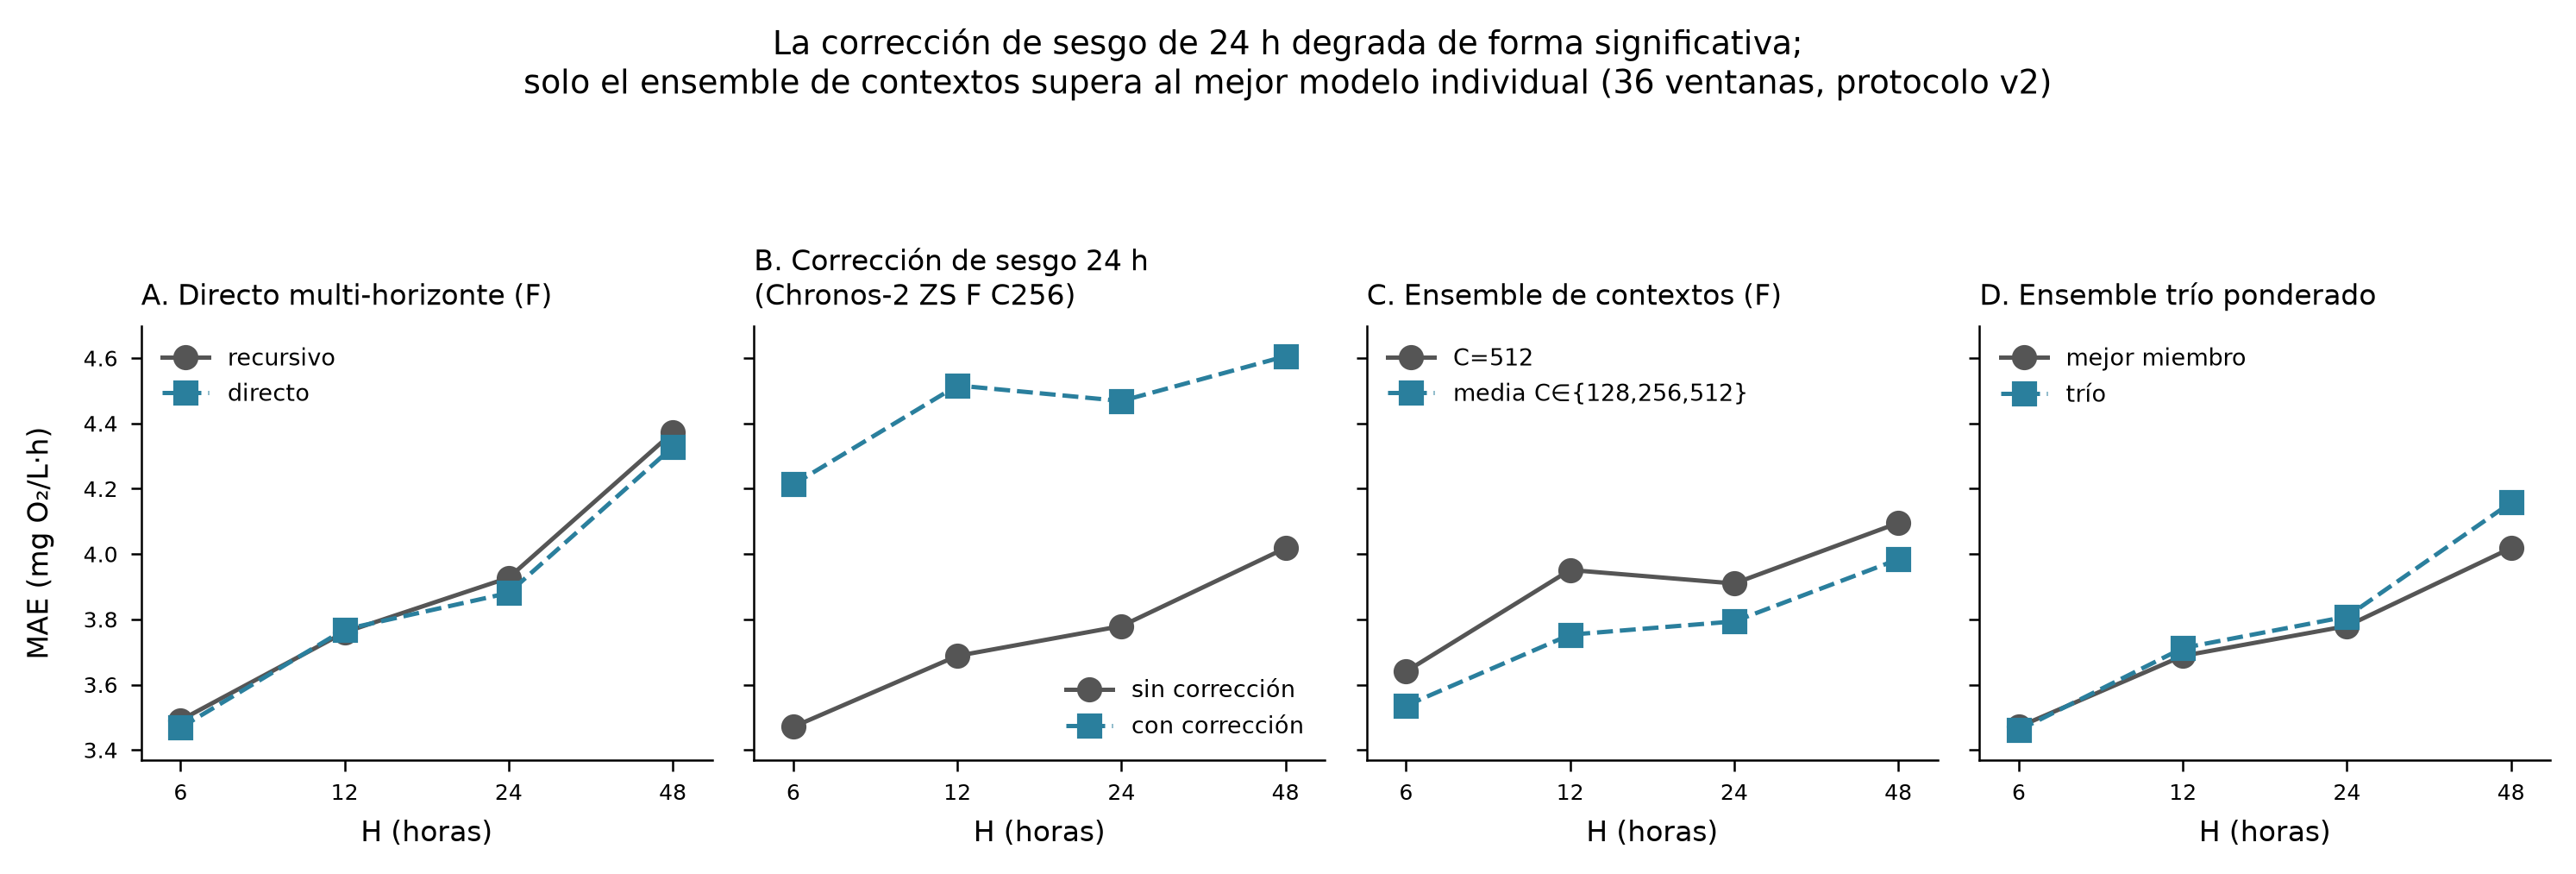

In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
res = pd.read_csv("results/mejoras.csv")
HORIZONS = [6, 12, 24, 48]
tecnicas = [
    ("A. Directo multi-horizonte (F)", "xgb_dir_F", "xgb_rec_E3", "recursivo", "directo"),
    ("B. Corrección de sesgo 24 h\n(Chronos-2 ZS F C256)", "c2_zs_F_C256_sesgo", "c2_zs_F_C256", "sin corrección", "con corrección"),
    ("C. Ensemble de contextos (F)", "ens_ctx_F", "c2_zs_F_C512", "C=512", "media C∈{128,256,512}"),
    ("D. Ensemble trío ponderado", "ens_trio_pond", "c2_zs_F_C256", "mejor miembro", "trío"),
]
fig, axes = plt.subplots(1, 4, figsize=(10, 3.0), sharey=True)
for ax, (titulo, mej, ref, lref, lmej) in zip(axes, tecnicas):
    ax.plot(HORIZONS, [res[(res.config==ref) & (res.H==H)].MAE.iloc[0] for H in HORIZONS],
            "o-", color="#555555", label=lref)
    ax.plot(HORIZONS, [res[(res.config==mej) & (res.H==H)].MAE.iloc[0] for H in HORIZONS],
            "s--", color="#2a7f9d", label=lmej)
    ax.set_xscale("log", base=2); ax.set_xticks(HORIZONS); ax.set_xticklabels(HORIZONS)
    ax.set_title(titulo, fontsize=8)
    ax.set_xlabel("H (horas)")
    ax.legend(frameon=False, fontsize=6.5,
              loc="lower right" if titulo.startswith("B.") else "upper left")
    ax.margins(0.08)
axes[0].set_ylabel("MAE (mg O₂/L·h)", labelpad=8)
fig.suptitle("La corrección de sesgo de 24 h degrada de forma significativa;\n"
             "solo el ensemble de contextos supera al mejor modelo individual (36 ventanas, protocolo v2)",
             fontsize=9, y=1.10)
fig.tight_layout()
fig.savefig("figures/fig_mejoras.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusión

Ver `resumen_mejoras.md` para la lectura completa con cifras y p-valores. Las cuatro técnicas se
evaluaron sobre las mismas 36 ventanas con contraste DM-HLN frente a su referencia sin mejora.